<a href="https://colab.research.google.com/github/eshaswain07-esha7/My-Colab-Project/blob/main/clinic_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Clinic Patient Admissions Analysis

**Author:** Anindita Swain  
**Date:** May 2026  
**Dataset:** Clinic Patient Admissions (Dec 2025 – Jan 2026)

---

## Overview

This notebook analyzes a clinic dataset containing patient admission records across December 2025 and January 2026. The analysis focuses on:

1. **Dataset Overview** – Loading and exploring the data structure
2. **Peak Admission Days** – Identifying the busiest days in January 2026
3. **Doctor Workload Analysis** – Ranking the busiest doctors in January 2026
4. **Month-over-Month Comparison** – Comparing doctor activity: Dec 2025 vs Jan 2026
5. **Billing Analysis** – Total billing amount per doctor

**Key Findings:**
- Jan 2nd and Jan 22nd were the busiest admission days in January 2026 (2 patients each)
- Dr. Robert Chen was the busiest doctor in January 2026 (3 patients)
- Dr. Alan Patel and Dr. Robert Chen both saw more patients in January compared to December
- Dr. Sarah Jenkins led overall billing revenue

---
## 1. Setup & Data Loading


In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
import os
from google.colab import files
import pandas as pd # Added this line

file_path = 'clinic dataset.xlsx'

# Check if the file already exists in the current directory
if not os.path.exists(file_path):
    # If not, prompt the user to upload it
    print(f"'{file_path}' not found. Please upload the file.")
    uploaded = files.upload()
    # Assuming the user uploads the correct file, it will be in the 'uploaded' dictionary
    # No need to rename as it will be saved with its original name in /content/
    if file_path not in uploaded:
        print(f"Warning: The uploaded file was not named '{file_path}'. Please ensure the correct file is uploaded.")
else:
    print(f"'{file_path}' found. Skipping upload.")

df = pd.read_excel(file_path)

# Parse dates
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'])

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Date range: {df["Admission_Date"].min().date()} to {df["Admission_Date"].max().date()}')

'clinic dataset.xlsx' found. Skipping upload.
Dataset loaded: 13 rows, 13 columns
Date range: 2025-12-01 to 2026-01-23


---
## 2. Dataset Overview


In [ ]:
# Preview the first few rows
df.head()

,Patient_ID,Patient_Name,Age,Gender,Blood_Type,Medical_Condition,Admission_Date,Discharge_Date,Doctor_Name,Hospital_Department,Billing_Amount,Insurance_Provider,Admission_Type
0,PT-101,John Smith,45,M,A+,Hypertension,2025-12-01,2025-12-04,Dr. Sarah Jenkins,Cardiology,4250,Blue Cross,Emergency
1,PT-102,Emily Davis,29,F,O-,Asthma,2025-12-03,2025-12-03,Dr. Robert Chen,Pulmonology,1200,Aetna,Outpatient
2,PT-103,Michael Brown,62,M,B+,Type 2 Diabetes,2025-12-05,2025-12-12,Dr. Sarah Jenkins,Endocrinology,8900,UnitedHealth,Urgent
3,PT-104,Jessica Taylor,34,F,AB+,Appendicitis,2025-12-10,2025-12-14,Dr. Alan Patel,General Surgery,12500,Cigna,Emergency
4,PT-105,David Wilson,71,M,O+,Heart Failure,2025-12-15,2025-12-22,Dr. Robert Chen,Cardiology,19800,Medicare,Urgent


In [ ]:
# Summary statistics
df.describe(include='all')

,Patient_ID,Patient_Name,Age,Gender,Blood_Type,Medical_Condition,Admission_Date,Discharge_Date,Doctor_Name,Hospital_Department,Billing_Amount,Insurance_Provider,Admission_Type
count,13,13,13.000000,13,13,13,13,13,13,13,13.000000,13,13
unique,13,13,NaN,2,8,5,NaN,NaN,3,4,NaN,5,4
top,PT-101,John Smith,NaN,M,A+,Hypertension,NaN,NaN,Dr. Sarah Jenkins,Cardiology,NaN,Blue Cross,Emergency
freq,1,1,NaN,7,3,3,NaN,NaN,5,6,NaN,3,4
mean,NaN,NaN,48.846154,NaN,NaN,NaN,2025-12-27 16:36:55.384615424,2025-12-31 14:46:09.230769152,NaN,NaN,9042.307692,NaN,NaN
min,NaN,NaN,28.000000,NaN,NaN,NaN,2025-12-01 00:00:00,2025-12-03 00:00:00,NaN,NaN,1150.000000,NaN,NaN
25%,NaN,NaN,34.000000,NaN,NaN,NaN,2025-12-10 00:00:00,2025-12-14 00:00:00,NaN,NaN,3100.000000,NaN,NaN
50%,NaN,NaN,50.000000,NaN,NaN,NaN,2026-01-02 00:00:00,2026-01-02 00:00:00,NaN,NaN,5400.000000,NaN,NaN
75%,NaN,NaN,62.000000,NaN,NaN,NaN,2026-01-15 00:00:00,2026-01-22 00:00:00,NaN,NaN,13100.000000,NaN,NaN
max,NaN,NaN,71.000000,NaN,NaN,NaN,2026-01-23 00:00:00,2026-01-30 00:00:00,NaN,NaN,24500.000000,NaN,NaN


---
## 3. Peak Admission Days — January 2026

Which days had the most patient admissions in January 2026?


In [ ]:
# Filter for January 2026
january_2026_df = df[(df['Admission_Date'].dt.year == 2026) & (df['Admission_Date'].dt.month == 1)]

# Group by date and count patients
daily_patients = (
    january_2026_df
    .groupby('Admission_Date')
    .size()
    .reset_index(name='Number_of_Patients')
    .sort_values('Number_of_Patients', ascending=False)
    .head(5)
)

print('Top 5 days with most patient admissions in January 2026:')
display(daily_patients)

Top 5 days with most patient admissions in January 2026:


,Admission_Date,Number_of_Patients
0,2026-01-02,2
3,2026-01-22,2
1,2026-01-03,1
2,2026-01-15,1
4,2026-01-23,1


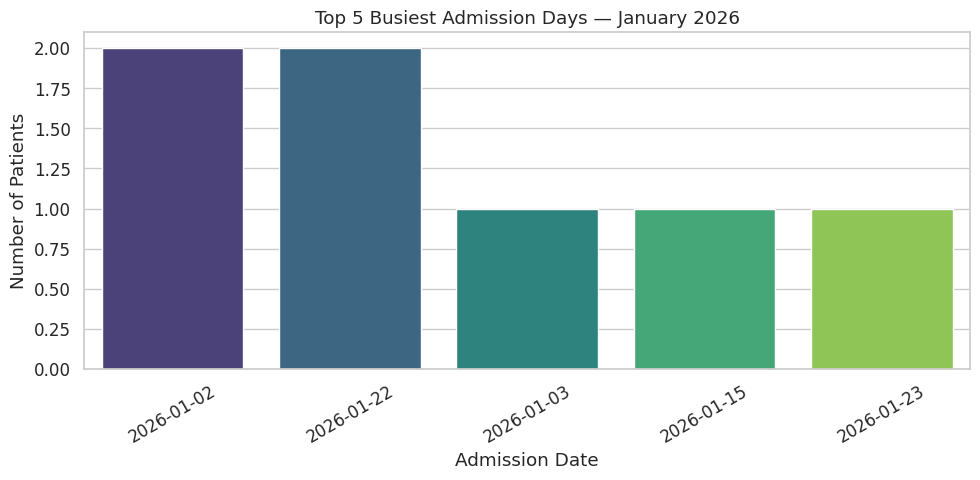

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x='Admission_Date', y='Number_of_Patients',
    data=daily_patients, palette='viridis',
    hue='Admission_Date', legend=False, ax=ax
)
ax.set_xlabel('Admission Date')
ax.set_ylabel('Number of Patients')
ax.set_title('Top 5 Busiest Admission Days — January 2026')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## 4. Busiest Doctors — January 2026

Which doctors handled the most patients in January 2026?


In [ ]:
# Count patients per doctor in January 2026
january_2026_admissions = df[(df['Admission_Date'].dt.year == 2026) & (df['Admission_Date'].dt.month == 1)]

top_5_doctors = (
    january_2026_admissions['Doctor_Name']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Number_of_Patients_Treated'})
    .head(5)
)

print('Top 5 busiest doctors in January 2026:')
display(top_5_doctors)

Top 5 busiest doctors in January 2026:


,Doctor_Name,Number_of_Patients_Treated
0,Dr. Robert Chen,3
1,Dr. Alan Patel,2
2,Dr. Sarah Jenkins,2


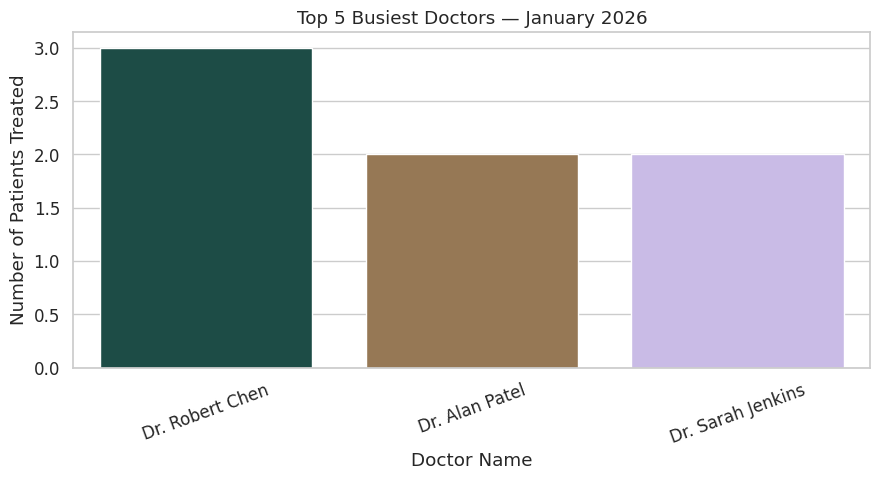

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    x='Doctor_Name', y='Number_of_Patients_Treated',
    data=top_5_doctors, palette='cubehelix',
    hue='Doctor_Name', legend=False, ax=ax
)
ax.set_xlabel('Doctor Name')
ax.set_ylabel('Number of Patients Treated')
ax.set_title('Top 5 Busiest Doctors — January 2026')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

---
## 5. Month-over-Month Doctor Comparison — Dec 2025 vs Jan 2026

Which doctors saw an increase in patient load from December 2025 to January 2026?


In [ ]:
# Count patients per doctor for each month
december_2025_admissions = df[(df['Admission_Date'].dt.year == 2025) & (df['Admission_Date'].dt.month == 12)]

dec_counts = (
    december_2025_admissions['Doctor_Name']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Patients_Dec_2025'})
)

jan_counts = (
    january_2026_admissions['Doctor_Name']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Patients_Jan_2026'})
)

# Merge and compute difference
combined = (
    pd.merge(dec_counts, jan_counts, on='Doctor_Name', how='outer')
    .fillna(0)
    .astype({'Patients_Dec_2025': int, 'Patients_Jan_2026': int})
)
combined['Difference'] = combined['Patients_Jan_2026'] - combined['Patients_Dec_2025']
combined = combined.sort_values('Difference', ascending=False)

print('Doctor patient counts — Dec 2025 vs Jan 2026:')
display(combined)

Doctor patient counts — Dec 2025 vs Jan 2026:


,Doctor_Name,Patients_Dec_2025,Patients_Jan_2026,Difference
0,Dr. Alan Patel,1,2,1
1,Dr. Robert Chen,2,3,1
2,Dr. Sarah Jenkins,3,2,-1


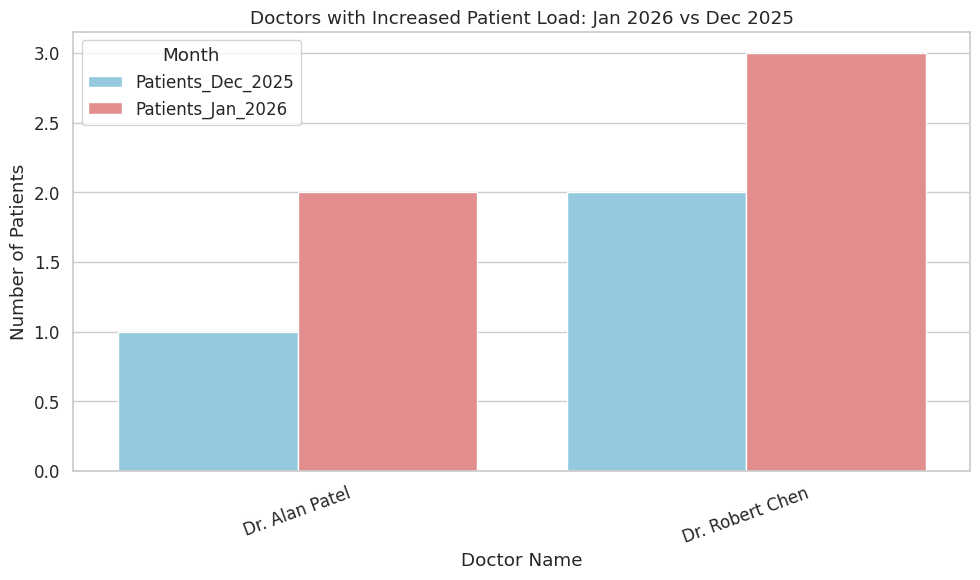

In [ ]:
# Doctors with increased patient load
increased = combined[combined['Difference'] > 0]

if not increased.empty:
    melted = increased.melt(
        id_vars='Doctor_Name',
        value_vars=['Patients_Dec_2025', 'Patients_Jan_2026'],
        var_name='Month', value_name='Number_of_Patients'
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        x='Doctor_Name', y='Number_of_Patients', hue='Month',
        data=melted,
        palette={'Patients_Dec_2025': 'skyblue', 'Patients_Jan_2026': 'lightcoral'},
        ax=ax
    )
    ax.set_xlabel('Doctor Name')
    ax.set_ylabel('Number of Patients')
    ax.set_title('Doctors with Increased Patient Load: Jan 2026 vs Dec 2025')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Month')
    plt.tight_layout()
    plt.show()
else:
    print('No doctors had an increased patient load in January 2026.')

---
## 6. Total Billing Amount per Doctor

Which doctors generated the most billing revenue across the full dataset?


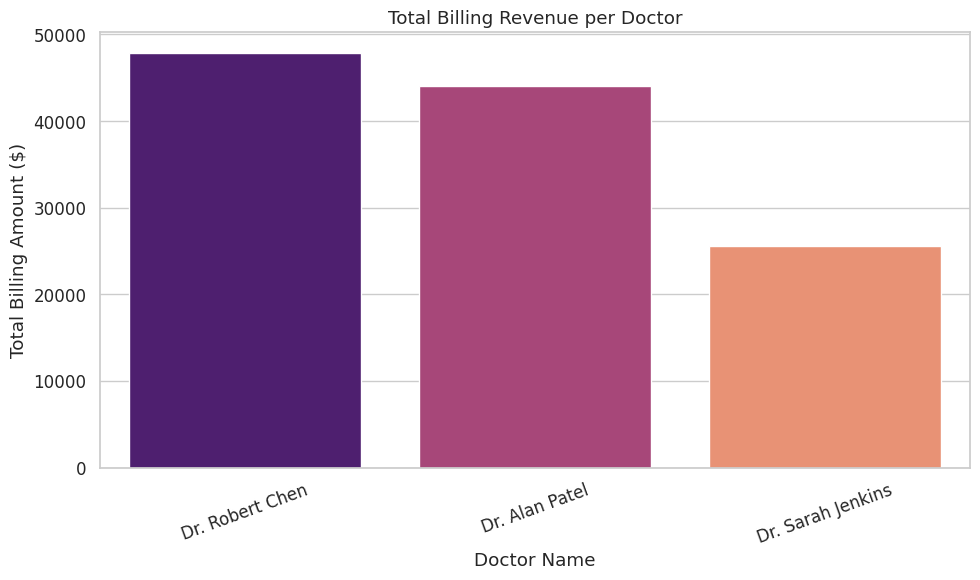

,Doctor_Name,Billing_Amount
1,Dr. Robert Chen,47900
0,Dr. Alan Patel,44100
2,Dr. Sarah Jenkins,25550


In [ ]:
doctor_billing = (
    df.groupby('Doctor_Name')['Billing_Amount']
    .sum()
    .reset_index()
    .sort_values('Billing_Amount', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x='Doctor_Name', y='Billing_Amount',
    data=doctor_billing, palette='magma',
    hue='Doctor_Name', legend=False, ax=ax
)
ax.set_xlabel('Doctor Name')
ax.set_ylabel('Total Billing Amount ($)')
ax.set_title('Total Billing Revenue per Doctor')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

display(doctor_billing)

---
## 7. Summary & Key Takeaways

| Insight | Finding |
|---|---|
| Busiest admission days (Jan 2026) | Jan 2nd and Jan 22nd (2 patients each) |
| Most active doctor (Jan 2026) | Dr. Robert Chen (3 patients) |
| Doctors with increased workload (Jan vs Dec) | Dr. Alan Patel (+1), Dr. Robert Chen (+1) |
| Highest billing revenue | Dr. Sarah Jenkins |

**Next Steps (suggested):**
- Expand the dataset to cover more months for trend analysis
- Add patient outcome metrics to correlate with billing and doctor workload
- Explore department-level admission patterns
